<a href="https://colab.research.google.com/github/alinas-git/Demand-forcasting/blob/main/demand_forcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Goals
* 1️⃣ Understand Sales Patterns:

  Analyze how sales change based on:
  * weekday vs weekend
  * promotions
  * price changes
  * time trends (monthly / yearly)
* 2️⃣ Identify Demand Trends
  Find patterns like:
  * which stores sell more
  * which items sell more
  * which days have higher demand
* 3️⃣ Predict Future Demand:
  
  Build a machine learning model to:
  * forecast sales for the upcoming months
  * calculate model accuracy to ensure reliable predictions
  * identify which factors (like history and lags) most affect future demand

# Setup

In [140]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline



from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
HGBR=HistGradientBoostingRegressor()
LR=LinearRegression()
RFR=RandomForestRegressor()
poly=PolynomialFeatures()

import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Colab Notebooks/retail_sales.csv"
df = pd.read_csv(path)


sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "axes.titleweight":"bold",
    "figure.figsize":(13,6),
    "axes.labelsize":13,
    "axes.titlesize":20,
    "axes.labelweight":"semibold",
    "text.color":"#301934",
    "grid.linestyle":":",
    "grid.alpha":0.9,
    "axes.grid":True
})


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [141]:
df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


In [142]:

df.isnull().sum()

,0
date,0
store_id,0
item_id,0
sales,0
price,0
promo,0
weekday,0
month,0


In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4565000 entries, 0 to 4564999
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   date      object 
 1   store_id  object 
 2   item_id   object 
 3   sales     int64  
 4   price     float64
 5   promo     int64  
 6   weekday   int64  
 7   month     int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 278.6+ MB


In [144]:
df["date"]=df["date"].astype("datetime64[ns]")
df["year"]=df["date"].dt.year.astype("int16")
df["month_name"]=df["date"].dt.month_name()
df=df.reset_index(drop=True)

monorder=["January","February","March","April","May","June","July","August","September","October","November","December"]
df["month_name"]=pd.Categorical(df["month_name"],categories=monorder,ordered=True)

df["day_name"]=pd.Categorical(
    df["date"].dt.day_name(),
    categories=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"],
    ordered=True,)

df["weekend"]=df["weekday"].isin([5,6]).astype("int8")
df["day"]=df["date"].dt.day


df["store_id"]=df["store_id"].str.replace("store_","").astype(int)
df["item_id"]=df["item_id"].str.replace("item_","").astype(int)

df = df[["date","day","day_name","month","month_name","weekday","year","promo","sales",'price',"item_id","store_id",]]


In [145]:
df.head(10)

,date,day,day_name,month,month_name,weekday,year,promo,sales,price,item_id,store_id
0,2019-01-01,1,Tuesday,1,January,1,2019,0,41,21.30,1,1
1,2019-01-02,2,Wednesday,1,January,2,2019,0,53,21.30,1,1
2,2019-01-03,3,Thursday,1,January,3,2019,0,39,21.30,1,1
3,2019-01-04,4,Friday,1,January,4,2019,0,35,21.30,1,1
4,2019-01-05,5,Saturday,1,January,5,2019,1,51,17.04,1,1
5,2019-01-06,6,Sunday,1,January,6,2019,0,38,21.30,1,1
6,2019-01-07,7,Monday,1,January,0,2019,0,45,21.30,1,1
7,2019-01-08,8,Tuesday,1,January,1,2019,0,48,21.30,1,1
8,2019-01-09,9,Wednesday,1,January,2,2019,0,50,21.30,1,1
9,2019-01-10,10,Thursday,1,January,3,2019,0,44,21.30,1,1


In [146]:
#checking the number of stores and families

In [147]:
print("number of items: ",len(df.item_id.unique()))
print("number of stores: ",len(df.store_id.unique()))

number of items:  50
number of stores:  50


# Exploratory Data Analysis (**EDA**)

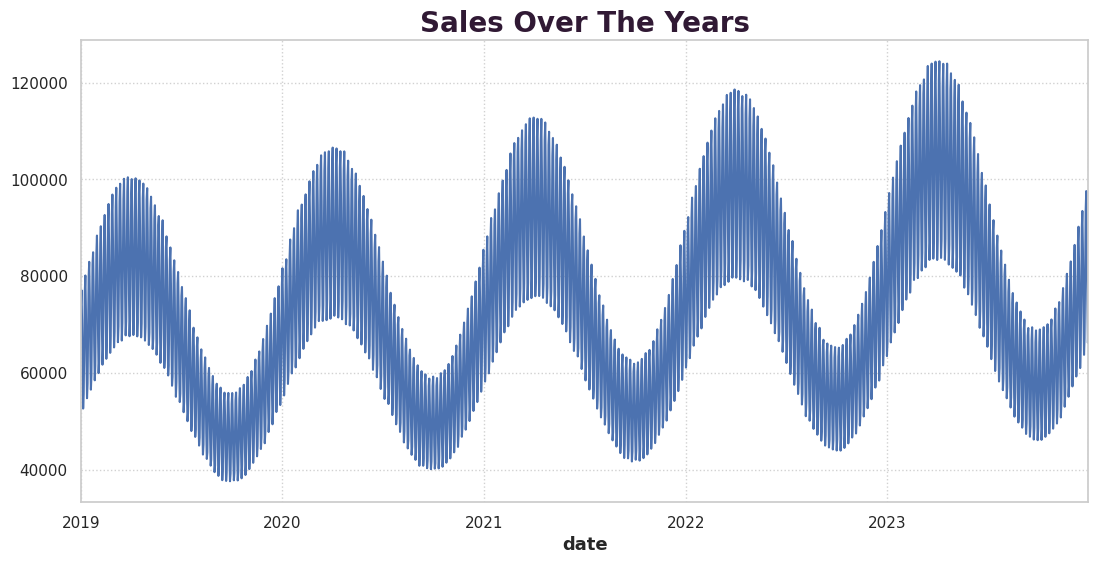

In [148]:
df.groupby("date")["sales"].sum().plot()
plt.title("Sales Over The Years")
plt.show()

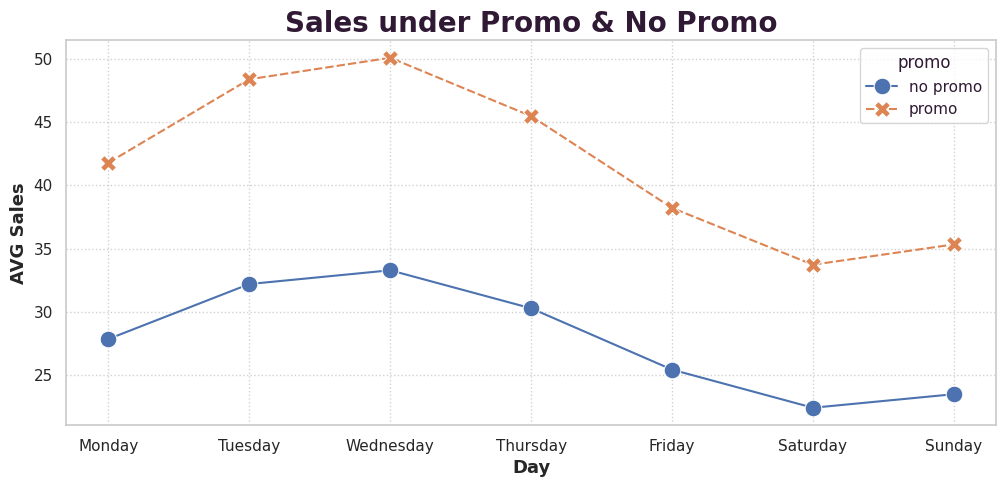

In [149]:
from os import rename
weekpro=(
df.groupby(["day_name","promo"],observed=True,as_index=False)["sales"].mean().rename(columns={"sales":"avg sales"}))
weekpro["promo"]=weekpro["promo"].map({0:"no promo",1:"promo"})

fig, ax =plt.subplots(figsize=(12,5))
sns.lineplot(
    data=weekpro,
    x="day_name",
    y="avg sales",
    hue="promo",
    style="promo",
    markers={"promo":"X","no promo":"o"},
    markersize=12
)
ax.set_title("Sales under Promo & No Promo")
ax.set_xlabel("Day")
ax.set_ylabel("AVG Sales")
plt.show()

**Promo vs No Promo Observation**
* Sales on **PROMO** days are clearly performing better than **NO PROMO** days.
* Both categories follow the saqme pattern ,with sales rising till wednesday and declining towards weekends.
* the distance between the two lines shows a reliable and consistent lift in sales.

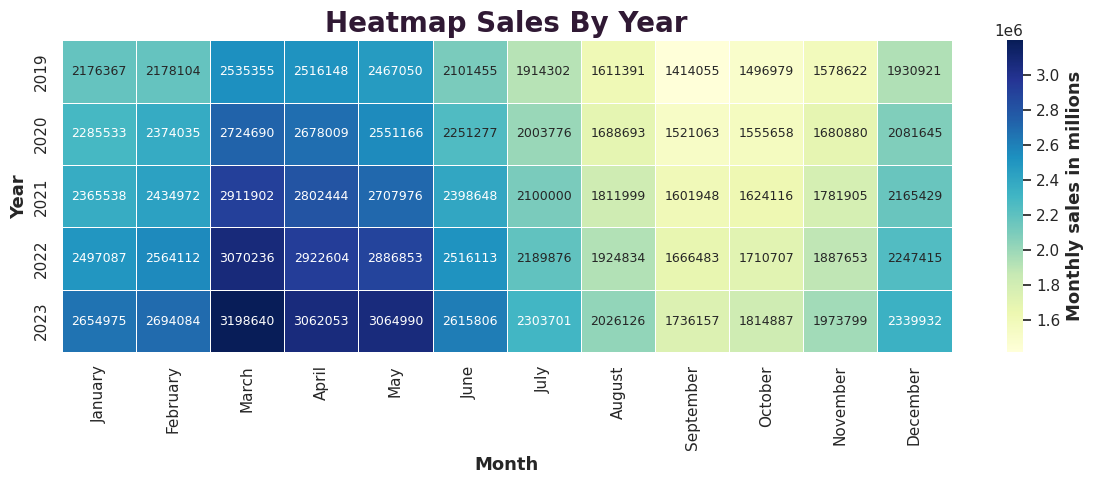

In [150]:
from matplotlib import axes
corr=df.corr(numeric_only=True)


fig,ax=plt.subplots(figsize=(12,5))
salespiv=df.pivot_table(index='year',columns="month_name",values="sales",aggfunc="sum")
sns.heatmap(
    salespiv,
    annot=True,
    annot_kws={"size":9},
    cmap="YlGnBu",
    fmt='.0f',
    ax=ax,
    lw=0.4,
    cbar_kws={"label":"Monthly sales in millions"})
ax.set_xlabel("Month")
ax.set_ylabel("Year")
ax.set_title("Heatmap Sales By Year")

plt.tight_layout()
plt.show()

**PEAK SEASON:**
* March,April and May are the consistant stronge months through out all the years.

**Annual Growth:**
* From 2019 to 2023, you can see the colors getting visibily darker,indicating a increase in total yearly sales overtime.

**Late YEAR DIP:**
* Starting from september the sales are dropping compare to the busy spring and summer months

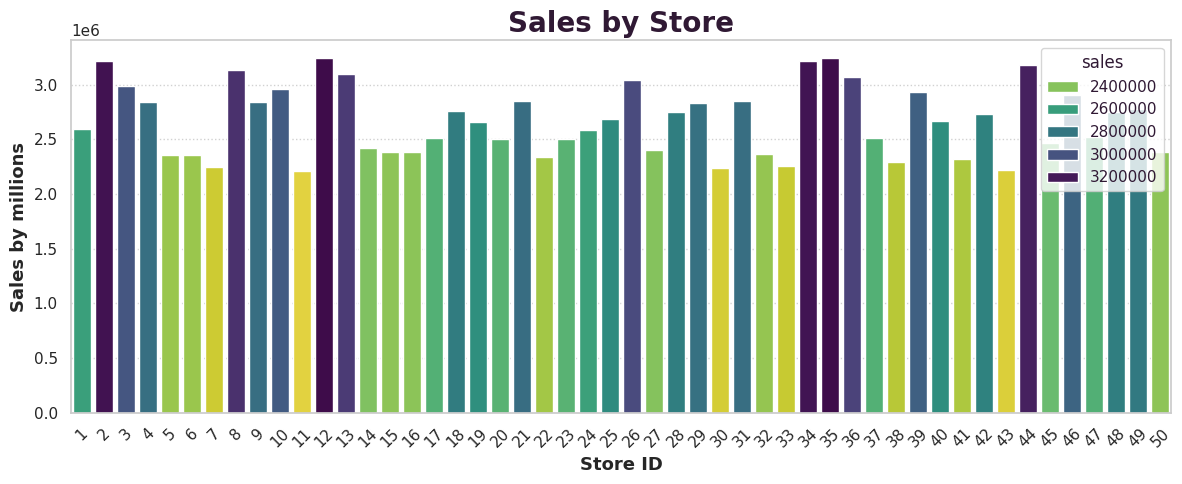

In [151]:
fig,ax=plt.subplots(figsize=(12,5))
storesales=df.groupby("store_id",as_index=False)["sales"].sum()
sns.barplot(data=storesales,x="store_id",y="sales",
            palette="viridis_r",
            edgecolor="white",
            hue="sales",
            ax=ax)
ax.set_title("Sales by Store")
ax.set_xlabel("Store ID")
ax.set_ylabel("Sales by millions")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Top Performing Stores:**
* Store 2, Store 12, Store 34, Store 35 and Store 44 are reaching the highest sales volumue (over 3 million).

**Targeted growth**
* The chart makes it easy to identify which stores are underperforming (the yellow short bars).
* The darker bars are highlighting high revenue generating stores or locations.

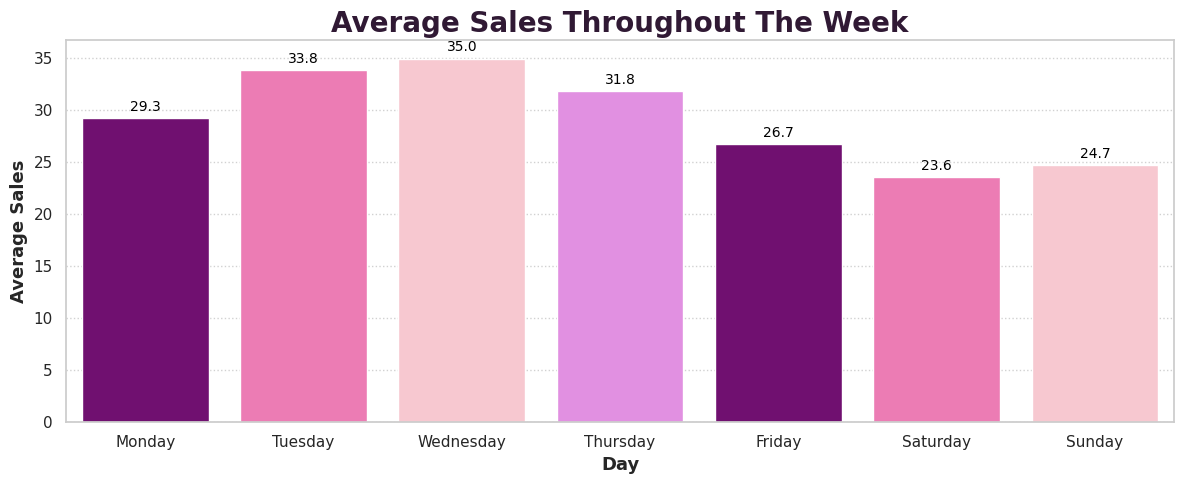

In [152]:
weeksales=(df.groupby("day_name",observed=True,as_index=False).agg(avg_sales=("sales","mean"),avg_price=("price","mean"),promo_rate=("promo","mean")))
fig,ax1=plt.subplots(figsize=(12,5))
sns.barplot(data=weeksales,x="day_name",y="avg_sales",palette=["purple","hotpink","pink",'violet'])

ax1.set_xlabel("Day")
ax1.set_ylabel("Average Sales")
ax1.set_title("Average Sales Throughout The Week",color = "#301934"  )

for p in ax1.patches:
    ax1.annotate(
        f"{p.get_height():.1f}",
        (p.get_x()+p.get_width()/2,p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0,3),
        textcoords="offset points",
        color="black"
    )

plt.tight_layout()
plt.show()


**Weekly Sales Performance Highlights:**
* From the start of the week, sales reach their highest point on Wednesday (35.0).
 Weekend Dip:
* Sales begin to drop after Thursday, hitting their lowest point on Saturday (23.6) before showing a slight recovery on Sunday.
* Since Monday through Thursday are your strongest days, these might be the best times to ensure the stores are fully staffed and stocked.


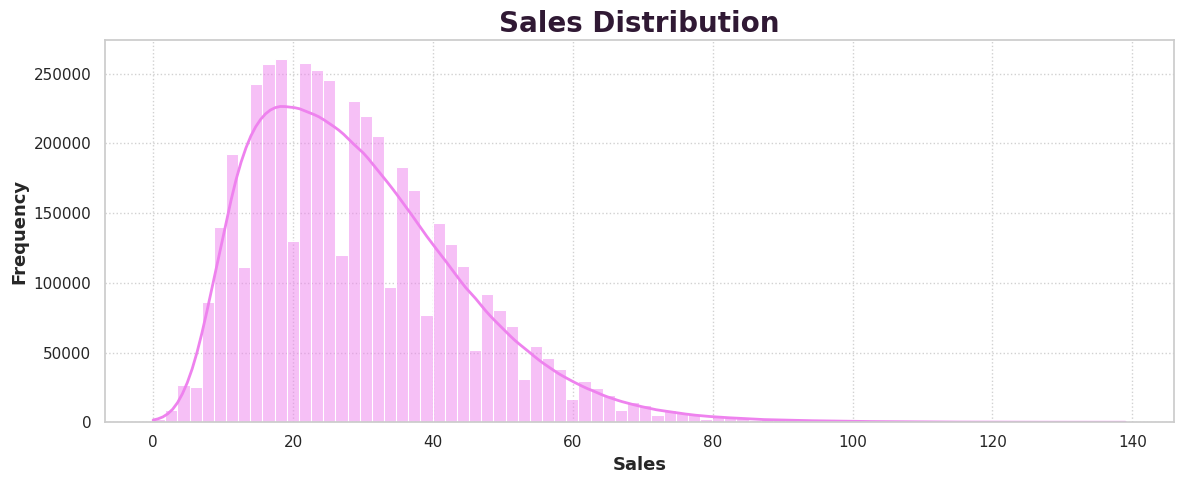

In [153]:
fig,ax=plt.subplots(figsize=(12,5))
sns.histplot(df['sales'],bins=80,kde=True,color="violet",line_kws={"color":"cyan",'linewidth':2})

ax.set_title("Sales Distribution")
ax.set_xlabel("Sales")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

**Most Common Sales & Outliers:**
* Most sales are concentrated in the 15–30 range, meanin most sales transactions are for smaller amounts, there are a few rare, very high-value sales.
* There is a long "tail" stretching to the right, showing that while rare, some customers make much larger purchases.
* Most of the chart is on the left, but those few high-value sales on the right side pull the overall average up.

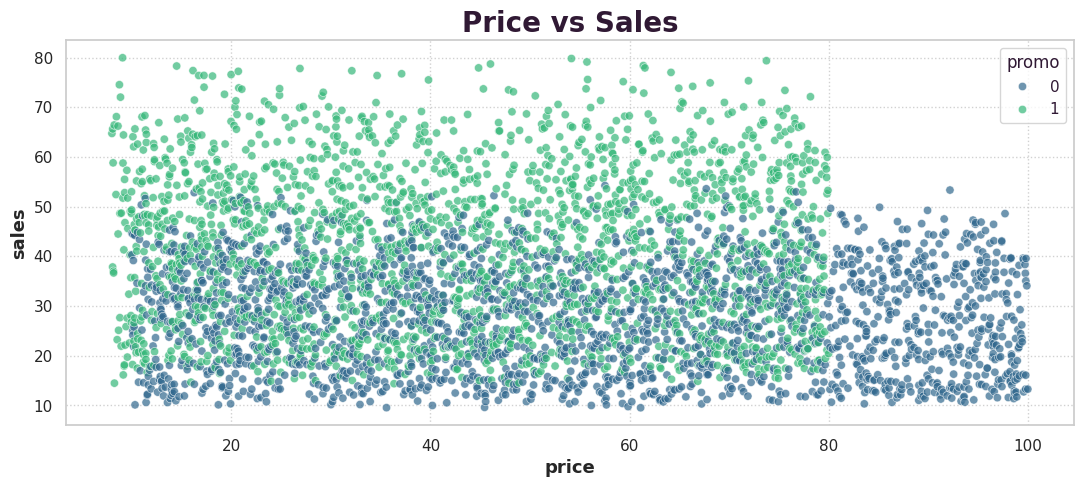

In [154]:
fig,ax=plt.subplots(figsize=(13,5))

pricesales=df.groupby(["price","promo"],as_index=False)["sales"].mean()
sns.scatterplot(data=pricesales,x="price",y="sales",alpha=0.7,palette="viridis",hue="promo")
ax.set_title("Price vs Sales")
plt.show()


* **Promo Limit:** Promotions are exclusively applied to items priced under 80, which is why the teal dots disappear completely on the right side of the chart.
* **Performance Gap:** For items under 80, the teal dots (Promo) are generally higher than the blue dots, showing that promotions successfully boost average sales.
* **High-Price Stability:** Items priced between 80 and 100 still sell consistently even without promotions, suggesting these products have their own steady demand.

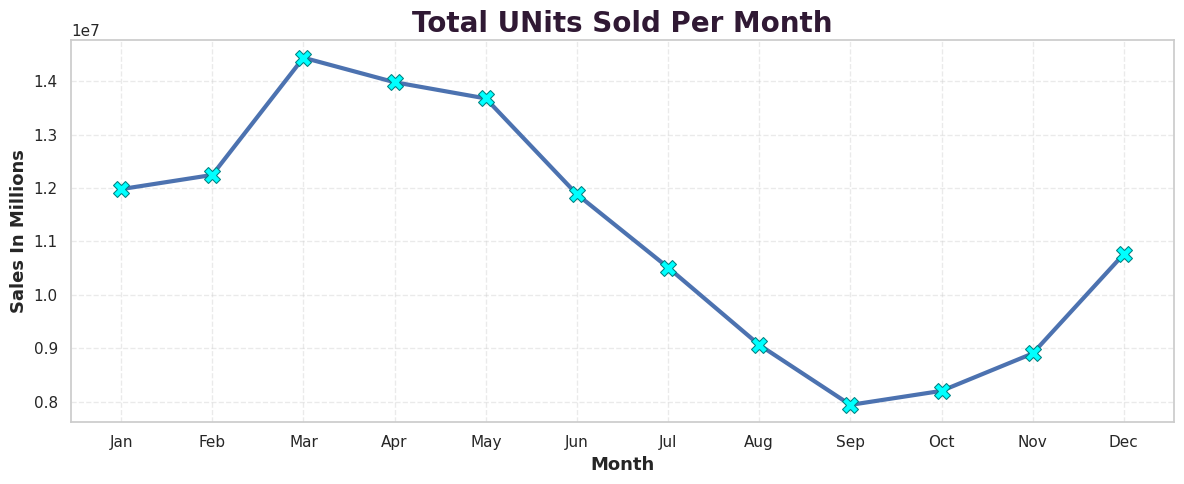

In [155]:
fig,ax=plt.subplots(figsize=(12,5))
import calendar

monthly=df.groupby("month",as_index=False)['sales'].sum()
monthly["month"]=monthly["month"].apply(lambda x: calendar.month_abbr[x])

sns.lineplot(data=monthly,x="month",y="sales",marker="X",palette="viridis_r",mfc="cyan",mec="teal",ms=11,lw=3)
ax.set_title("Total UNits Sold Per Month")
ax.set_xlabel("Month")
ax.set_ylabel("Sales In Millions")


plt.tight_layout()
plt.grid(linestyle="--",alpha=0.4)
plt.show()

**Spring:**
* Sales hit a yearly high in March at approximately 1.45 ($14.5$ million) units after a strong start to the year.

**September Low:**
* Following the spring peak, sales go into a steady decline through the summer, hitting the yearly bottom in September at 0.84 ($8.4$ million) units.

**Year-End Growth:**

* After the September low, the trend reverses and sales climb back up to reach approximately 1.14 ($11.4$ million) units by December

# **Forcasting**

In [156]:
df=df.drop(['month_name','day_name'],axis=1)
# df=df.sample(200000,random_state=43)

In [157]:
X, y=df.drop(["sales","date"],axis=1),df["sales"]

X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)
df.shape

(4565000, 10)

Testing Which Model Works Better


In [158]:
# for i in [HGBR,LR,RFR]:
#   i.fit(X_train,y_train)
#   score=i.score(X_test,y_test)
#   print(i,score)


In [159]:
model=HistGradientBoostingRegressor()
model.fit(X_train,y_train)

HistGradientBoostingRegressor()

 * Baseline With The Best Regressor

In [160]:
y_pred=model.predict(X_test)
r2=r2_score(y_test,y_pred)
r2

0.9297241776223685

# Improving the Accuracy (Feature Engineering)

In [161]:
# X,y=df.drop(["store_id","item_id","sales","date"],axis=1),df["sales"]
# X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

df["store_id"] = df["store_id"].astype("category")
df["item_id"] = df["item_id"].astype("category")

model=HistGradientBoostingRegressor()
model.fit(X_train,y_train)

y_pred=model.predict(X_test)
r2=r2_score(y_test,y_pred)
r2

0.9291350190668567

In [162]:
print("Dataframe before rolling and lag: ",df.shape)

df=df.sort_values(["store_id",'item_id',"date"])

df["sales_lag7"]=df.groupby(["store_id","item_id"])["sales"].shift(7)
df["sales_lag30"]=df.groupby(["store_id","item_id"])["sales"].shift(30)
df["rolling_mean7"]=df.groupby(["store_id","item_id"])["sales"].transform(lambda x: x.rolling(7).mean())

df = df.dropna().reset_index(drop=True)

print("Dataframe after rolling and lag: ",df.shape)

Dataframe before rolling and lag:  (4565000, 10)
Dataframe after rolling and lag:  (4490000, 13)


In [163]:
X, y=df.drop(["sales","date"],axis=1),df["sales"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=43)



In [164]:
model=HistGradientBoostingRegressor()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
r2=r2_score(y_test,y_pred)
r2

0.9576187359358914

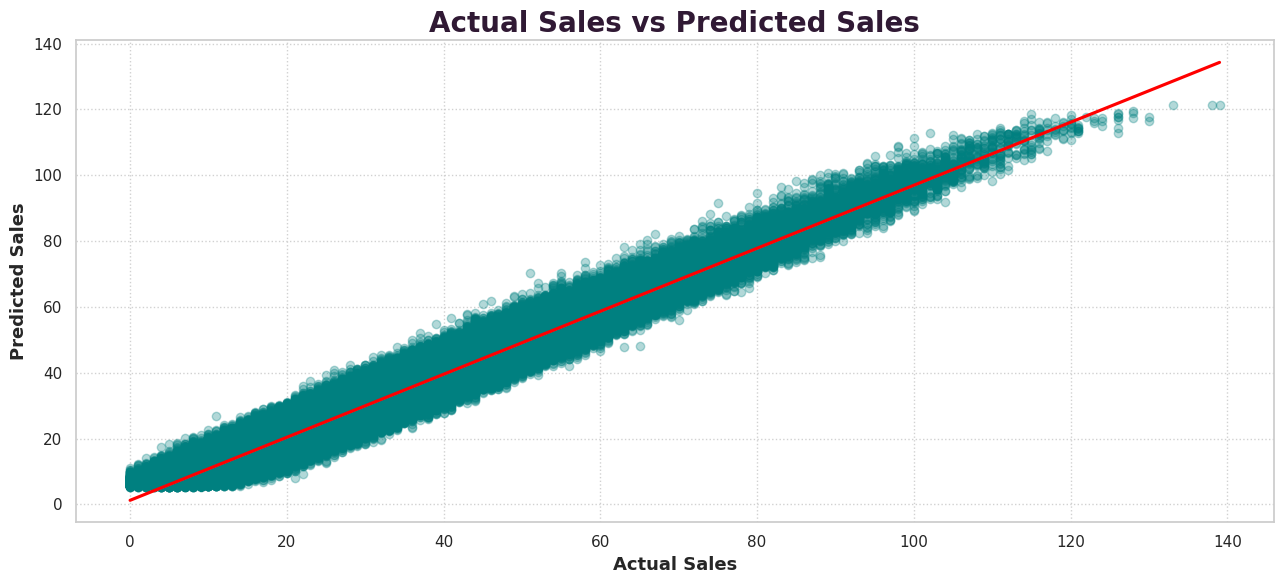

In [165]:
dflm=pd.DataFrame({
    "Actual_Sales":y_test,
    "Predicted_Sales":y_pred
})

sns.regplot(data=dflm,
           x="Actual_Sales",
           y="Predicted_Sales",
           line_kws={"color":"red"},
           scatter_kws={"alpha":0.3,"color":"teal"})
plt.title("Actual Sales vs Predicted Sales")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.tight_layout()
plt.show()

### Actual vs Predicted (Scatter Plot)

The points mostly line up with the diagonal, so the predictions are close to real sales.

A few points stick out — those are probably unusual days, like big promotions or stock issues.

Basically, this plot shows where the model is “off” and where it gets it right.

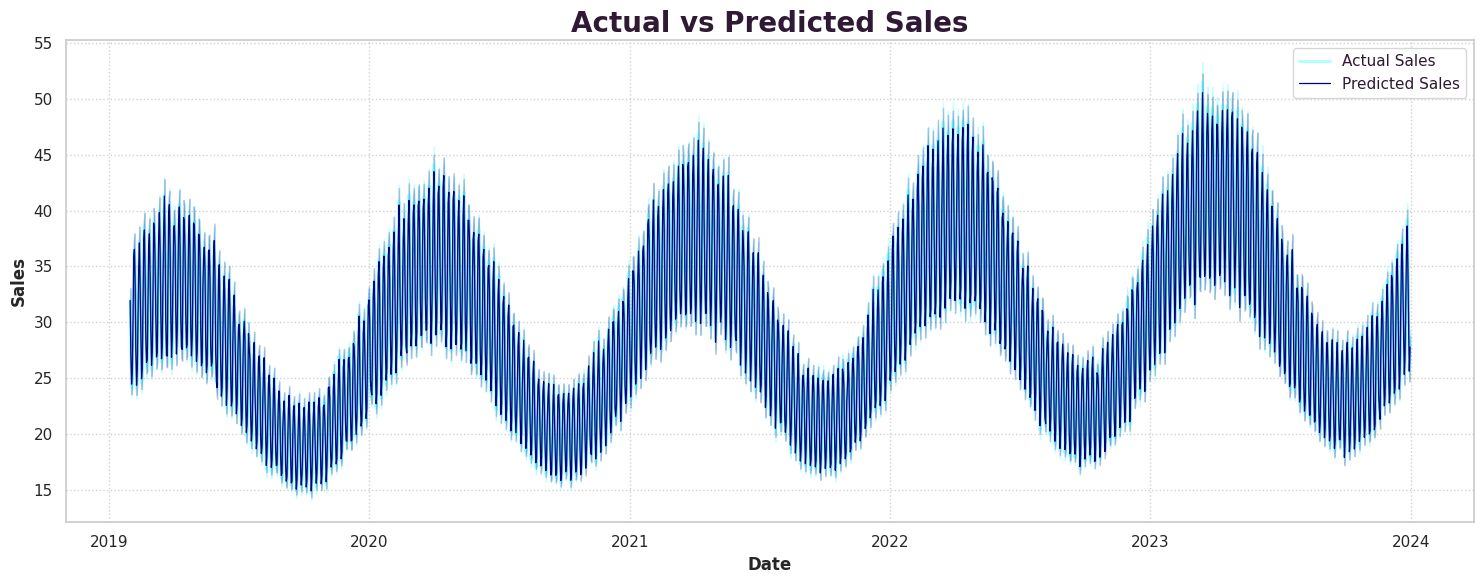

In [173]:
plot=pd.DataFrame({
    "date":df.loc[X_test.index,'date'],
    "Actual_sales":y_test,
    "Predicted_sales":y_pred
})
plot=plot.sort_values("date")
plot=plot.melt(id_vars="date",
               value_vars=["Actual_sales","Predicted_sales"],
               var_name="type",value_name="sales")

plt.figure(figsize=(15,6))


sns.lineplot(data=plot[plot["type"]=="Actual_sales"],
             x="date",
             y="sales",
             color="cyan",
             alpha=0.3,
             label="Actual Sales",
             lw=2.2)
sns.lineplot(data=plot[plot["type"]=="Predicted_sales"],
             x="date",
             y="sales",
             color="navy",
             alpha=1,
             label="Predicted Sales",
             lw=0.9)


plt.title("Actual vs Predicted Sales")
plt.xlabel("Date",fontsize=12)
plt.ylabel("Sales",fontsize=12)
plt.legend(title="")
plt.tight_layout()
plt.show()

### Actual vs Predicted (Time Series Line Plot)

 The predicted line follows the ups and downs of real sales pretty well, which means the model is picking up weekly or seasonal trends.

 Over the years, it mostly stays on track, so it’s not just guessing based on short-term patterns.

 Peaks in early spring match reasonably, though you can spot where it misses slightly or smooths out sudden jumps.

# Project Conclusion
**Model Success:** We successfully built a machine learning model that predicts sales with 95% accuracy, proving that historical trends and promotions are strong indicators of future performance.

**Key Insight:** The addition of "Lag" features (looking at the past 7 days) was the most important step, as it allowed the model to understand the immediate momentum of sales.

**Business Value:** With this high level of precision, the business can now confidently plan inventory and staffing levels based on the model's seasonal and promotional forecasts.